# Multicollinearity and Influential Points

In this notebook we will identify multicollinearity in a set of predictors and demonstrate how it causes issues with modeling. We will also show how we can identify outliers, or **influential** points. We'll be using the **Credit** data for this exercise.

In [124]:
# Detect Multicollinearity 
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [125]:
# 1. We want to create a heatmap for pairwise correlations

credit = pd.read_csv("../Data/Credit.csv")
credit['Income'] = pd.to_numeric(credit['Income'])
credit.sample(5)

,Unnamed: 0,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
363,364,64.173,6127,433,1,80,10,Male,No,Yes,Caucasian,578
286,287,18.036,1552,142,2,48,15,Female,No,No,Caucasian,0
230,231,33.214,5137,387,3,59,9,Male,No,No,African American,661
85,86,152.298,12066,828,4,41,12,Female,No,Yes,Asian,1779
257,258,15.629,2493,186,1,60,14,Male,No,Yes,Asian,0


In [126]:
# We need the numeric variables for the correlation matrix
quantitative_vars = [ 'Balance', 'Income', 'Limit', 'Rating', 'Cards', 'Age']

# Calculate the correlation matrix
corr_matrix = credit[quantitative_vars].corr()
corr_matrix

,Balance,Income,Limit,Rating,Cards,Age
Balance,1.000000,0.463656,0.861697,0.863625,0.086456,0.001835
Income,0.463656,1.000000,0.792088,0.791378,-0.018273,0.175338
Limit,0.861697,0.792088,1.000000,0.996880,0.010231,0.100888
Rating,0.863625,0.791378,0.996880,1.000000,0.053239,0.103165
Cards,0.086456,-0.018273,0.010231,0.053239,1.000000,0.042948
Age,0.001835,0.175338,0.100888,0.103165,0.042948,1.000000


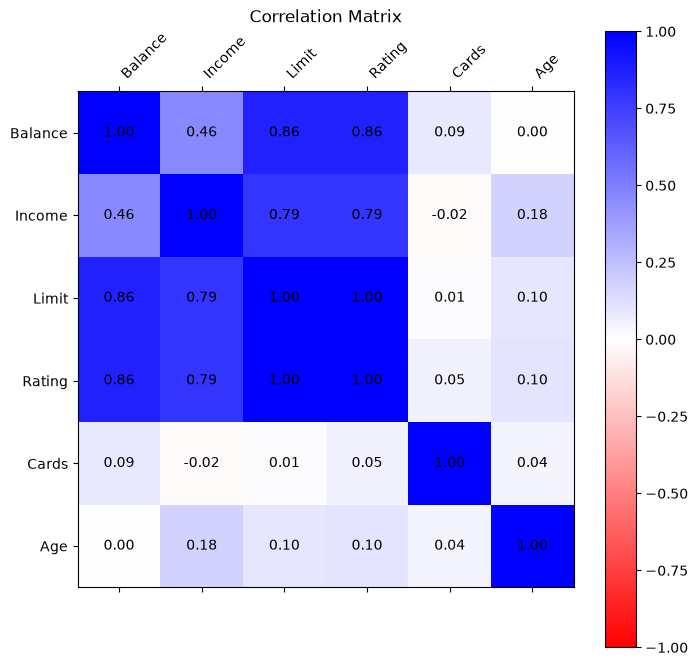

In [127]:
# For visulaization purposes, to spot highly correlated predictors, we can use a heatmap.
import matplotlib.colors as mcolors

# Create a custom diverging colormap where 0 is explicitly white
cmap = mcolors.LinearSegmentedColormap.from_list('custom_coolwarm', ['red', 'white', 'blue'], N=256)

# Create a plot to visualize the correlation matrix with white for zero
fig, ax = plt.subplots(figsize=(8, 8))

# Apply the custom colormap to the heatmap
cax = ax.matshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1)

# Add color bar to the side
plt.colorbar(cax)

# Set the ticks for the x and y axis
ax.set_xticks(range(len(quantitative_vars)))
ax.set_yticks(range(len(quantitative_vars)))

# Set the labels for the ticks
ax.set_xticklabels(quantitative_vars, rotation=45, ha='left')
ax.set_yticklabels(quantitative_vars)

# Annotate the correlation matrix with the numeric values
for (i, j), val in np.ndenumerate(corr_matrix):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

# Display the plot
plt.title("Correlation Matrix")
plt.show()


### Note:

- We are only comparing quantitative predictors here, not categorical. 
- Think: how can we measure the "correlation" between categorical variables? Or categorical variables vs. quantitative variables? It is not straightforward.

### Problem with identifying with correlations:
- It characterizes pairwise relationships, but does not evaluate all features' joint correlations together.
- It doesn't make sense out of the box for categorical variables. 

We can use the variance inflation factors to identify predictors that are linear combinations of more than one other predictor since the correlation is only a pairwise metric.

In [128]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices #an alternative to basic pandas dfs.

# Create the design matrices using patsy
y, X = dmatrices('Balance ~ Income + Limit + Rating + Cards + \
                  Age + Education + Gender + Student + Married + Ethnicity', 
                  data=credit, return_type='dataframe')
X

,Intercept,Gender[T.Female],Student[T.Yes],Married[T.Yes],Ethnicity[T.Asian],Ethnicity[T.Caucasian],Income,Limit,Rating,Cards,Age,Education
0,1.0,0.0,0.0,1.0,0.0,1.0,14.891,3606.0,283.0,2.0,34.0,11.0
1,1.0,1.0,1.0,1.0,1.0,0.0,106.025,6645.0,483.0,3.0,82.0,15.0
2,1.0,0.0,0.0,0.0,1.0,0.0,104.593,7075.0,514.0,4.0,71.0,11.0
3,1.0,1.0,0.0,0.0,1.0,0.0,148.924,9504.0,681.0,3.0,36.0,11.0
4,1.0,0.0,0.0,1.0,0.0,1.0,55.882,4897.0,357.0,2.0,68.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...
395,1.0,0.0,0.0,1.0,0.0,1.0,12.096,4100.0,307.0,3.0,32.0,13.0
396,1.0,0.0,0.0,0.0,0.0,0.0,13.364,3838.0,296.0,5.0,65.0,17.0
397,1.0,1.0,0.0,1.0,0.0,1.0,57.872,4171.0,321.0,5.0,67.0,12.0
398,1.0,0.0,0.0,1.0,0.0,1.0,37.728,2525.0,192.0,1.0,44.0,13.0


In [129]:

# Use the design matrix to calculate the VIF for each feature
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
print(vif)

    VIF Factor                features
0    52.451853               Intercept
1     1.005849        Gender[T.Female]
2     1.031517          Student[T.Yes]
3     1.044638          Married[T.Yes]
4     1.552157      Ethnicity[T.Asian]
5     1.527504  Ethnicity[T.Caucasian]
6     2.786182                  Income
7   234.028100                   Limit
8   235.848259                  Rating
9     1.448690                   Cards
10    1.051410                     Age
11    1.019588               Education


The intercept has a high VIF, but we don't really care about that. We'll leave it in. Limit and Rating are also identified as variables that are causing the multicolinearity problem. Since they are highly correlated, we can consider deleting one. Let's try to delete Limit.

In [130]:
# Deleting limit improves VIFs considerably
y, X_new = dmatrices('Balance~ Income + Rating + Cards + \
                      Age + Education + Gender + Student + Married + Ethnicity', 
                      data=credit, return_type='dataframe')
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_new.values, i) for i in range(X_new.shape[1])]
vif["features"] = X_new.columns
print(vif) 

    VIF Factor                features
0    46.513331               Intercept
1     1.005848        Gender[T.Female]
2     1.022092          Student[T.Yes]
3     1.032237          Married[T.Yes]
4     1.546515      Ethnicity[T.Asian]
5     1.527415  Ethnicity[T.Caucasian]
6     2.784966                  Income
7     2.730561                  Rating
8     1.019639                   Cards
9     1.051135                     Age
10    1.013503               Education


In [131]:
# First, fit model with Limit AND Rating 
model = smf.ols('Balance ~ Income + Limit + Rating + Cards + \
                Age + Education + Gender + Student + Married + Ethnicity', data=credit).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     750.3
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          1.11e-253
Time:                        14:59:06   Log-Likelihood:                -2398.7
No. Observations:                 400   AIC:                             4821.
Df Residuals:                     388   BIC:                             4869.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               -479.2079     35.774    -13.395      0.000    -549.543    -408.873
Gender[T.Female]         -10.6532      9.914     -1.075      0.283     -30.145       8.839
Student[T.Yes]           425.7474     16.723     25.459      0.000     392.869     458.626
Married[T.Yes]            -8.5339     10.363     -0.824      0.411     -28.908      11.841
Ethnicity[T.Asian]        16.8042     14.119      1.190      0.235     -10.955      44.564
Ethnicity[T.Caucasian]    10.1070     12.210      0.828      0.408     -13.899      34.113
Income                    -7.8031      0.234    -33.314      0.000      -8.264      -7.343
Limit                      0.1909      0.033      5.824      0.000       0.126       0.255
Rating                     1.1365      0.491      2.315      0.021       0.171       2.102
Cards                     17.7245      4.341      4.083      0.000       9.190      26.259
Age                       -0.6139      0.294     -2.088      0.037      -1.192      -0.036
Education                 -1.0989      1.598     -0.688      0.492      -4.241       2.043
==============================================================================
Omnibus:                       34.899   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               41.766
Skew:                           0.782   Prob(JB):                     8.52e-10
Kurtosis:                       3.241   Cond. No.                     3.87e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.87e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [132]:
# Now fit new model without limit, since it is highly correlated with rating.
model = smf.ols('Balance ~ Income + Rating + Cards + \
                Age + Education + Gender + Student + Married + Ethnicity', data=credit).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     757.8
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          4.46e-248
Time:                        14:59:06   Log-Likelihood:                -2415.4
No. Observations:                 400   AIC:                             4853.
Df Residuals:                     389   BIC:                             4897.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               -549.3140     35.085    -15.657      0.000    -618.293    -480.335
Gender[T.Female]         -10.7106     10.325     -1.037      0.300     -31.010       9.589
Student[T.Yes]           416.4376     17.336     24.021      0.000     382.353     450.522
Married[T.Yes]           -15.1096     10.728     -1.408      0.160     -36.202       5.983
Ethnicity[T.Asian]        21.7616     14.678      1.483      0.139      -7.096      50.619
Ethnicity[T.Caucasian]    10.6492     12.716      0.837      0.403     -14.351      35.649
Income                    -7.7746      0.244    -31.878      0.000      -8.254      -7.295
Rating                     3.9790      0.055     72.332      0.000       3.871       4.087
Cards                      3.9654      3.793      1.045      0.296      -3.492      11.422
Age                       -0.6416      0.306     -2.096      0.037      -1.243      -0.040
Education                 -0.3799      1.659     -0.229      0.819      -3.642       2.882
==============================================================================
Omnibus:                       15.651   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               16.769
Skew:                           0.490   Prob(JB):                     0.000228
Kurtosis:                       2.789   Cond. No.                     2.73e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.73e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

How different is the model above when we removed one of the highly correlated predictors? Take a look at the p-values for each coefficient, and look at the coefficients themselves, and the standard errors. Sometimes, a coefficient might look like it has barely changed, but when you check the standard error, you'll see that it has changed by quite a lot of standard errors. 

#### Perfect Collinearity

Let's create a feature that is perfectly correlated with one of our others and see what happens. You'll notice that the model will still be fit. The statsmodels library can still compute the inverse of the $X^TX$ matrix using a different method, but look at the very bottom of the summary, in the fine print. You'll see a *warning* about your matrix, which tells you not to fully trust the results.

In [133]:
# Create a new feature that is a linear combination of the two highly correlated features.
credit['Limit_Rating'] = credit['Limit']*2

# Fit a model with the new feature
model = smf.ols('Balance ~ Income + Rating + Limit + Limit_Rating + Cards + \
                Age + Education + Gender + Student + Married + Ethnicity', data=credit).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     750.3
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          1.11e-253
Time:                        14:59:06   Log-Likelihood:                -2398.7
No. Observations:                 400   AIC:                             4821.
Df Residuals:                     388   BIC:                             4869.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               -479.2079     35.774    -13.395      0.000    -549.543    -408.873
Gender[T.Female]         -10.6532      9.914     -1.075      0.283     -30.145       8.839
Student[T.Yes]           425.7474     16.723     25.459      0.000     392.869     458.626
Married[T.Yes]            -8.5339     10.363     -0.824      0.411     -28.908      11.841
Ethnicity[T.Asian]        16.8042     14.119      1.190      0.235     -10.955      44.564
Ethnicity[T.Caucasian]    10.1070     12.210      0.828      0.408     -13.899      34.113
Income                    -7.8031      0.234    -33.314      0.000      -8.264      -7.343
Rating                     1.1365      0.491      2.315      0.021       0.171       2.102
Limit                      0.0382      0.007      5.824      0.000       0.025       0.051
Limit_Rating               0.0764      0.013      5.824      0.000       0.051       0.102
Cards                     17.7245      4.341      4.083      0.000       9.190      26.259
Age                       -0.6139      0.294     -2.088      0.037      -1.192      -0.036
Education                 -1.0989      1.598     -0.688      0.492      -4.241       2.043
==============================================================================
Omnibus:                       34.899   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               41.766
Skew:                           0.782   Prob(JB):                     8.52e-10
Kurtosis:                       3.241   Cond. No.                     1.77e+17
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.76e-24. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

### Simulated Example

In this section let's simulate some data ourselves so that we can control the amount of correlation.

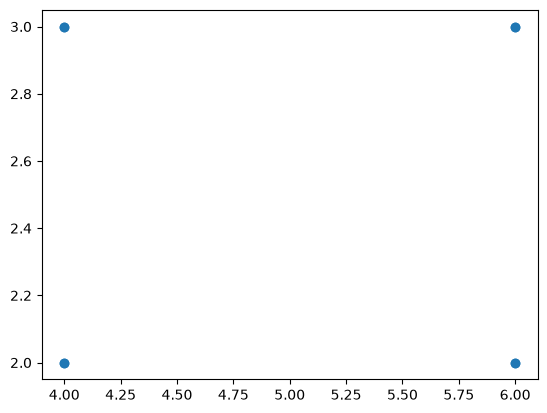

In [134]:
# Uncorrelated predictor variables
X1 = [4, 4, 4, 4, 6, 6, 6, 6]
X2 = [2, 2, 3, 3, 2, 2, 3, 3]
Y = [42, 39, 48, 51, 49, 53, 61, 60]

df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'Y': Y
})

# Plot a scatterplot of X2 against X1
plt.scatter(df['X1'], df['X2'])

In [135]:
# Let's check that there is no correlation between X1 and X2
correlation = np.corrcoef(X1, X2)[0, 1]
print(f'Correlation between X1 and X2: {correlation}')

Correlation between X1 and X2: 0.0


Now let's fit three models and compare the coefficients.

In [136]:
# Linear model Y ~ X1 + X2
# Let's check coefficients for the model
model1 = smf.ols('Y ~ X1 + X2', data=df).fit()
model1.params

Intercept    0.375
X1           5.375
X2           9.250
dtype: float64

In [137]:
model2 = smf.ols('Y ~ X1', data=df).fit()
model2.params

Intercept    23.500
X1            5.375
dtype: float64

In [138]:
model3 = smf.ols('Y ~ X2', data=df).fit()
model3.params

Intercept    27.25
X2            9.25
dtype: float64

**Question:** What did you notice about the coefficients?

#### Now let's simulate a perfectly correlated dataset

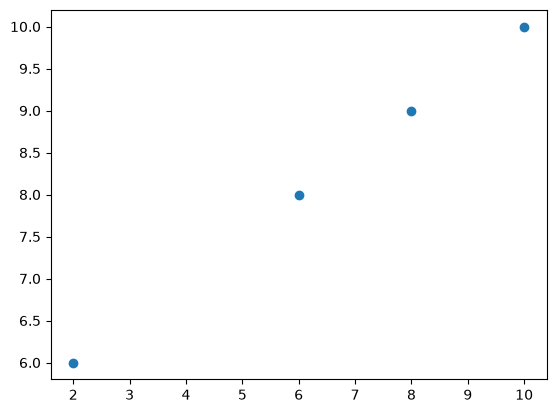

In [139]:
# Perfectly correlated case
X1 = [2, 8, 6, 10]
X2 = [6, 9, 8, 10]
Y = [23, 83, 63, 103]

df_perfect = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'Y': Y
})

# Plot a scatterplot of X2 against X1
plt.scatter(df_perfect['X1'], df_perfect['X2'])

In [140]:
correlation_perfect = np.corrcoef(X1, X2)[0, 1]
print(f'Correlation between X1 and X2: {correlation_perfect}')

Correlation between X1 and X2: 1.0


Let's create the design matrix and do some of the linear algebra ourselves.

In [141]:
X = np.column_stack([np.ones(len(X1)), X1, X2])
X

array([[ 1.,  2.,  6.],
       [ 1.,  8.,  9.],
       [ 1.,  6.,  8.],
       [ 1., 10., 10.]])

In [142]:
# Matrix operations

XtX = np.dot(X.T, X)

# Look at the eigenvalues of XtX to see if it is singular or near singular
eigenvalues = np.linalg.eigvals(XtX)
print(f'Eigenvalues:\n{eigenvalues}') # 2nd eigen val very close to zero 
# numerically near singular

Eigenvalues:
[ 4.81365468e+02+0.j -1.27267426e-15+0.j  7.63453185e+00+0.j]


In [143]:
import scipy.linalg as spla

# Attempt to invert the matrix
XtX_inv = spla.solve(XtX, np.eye(3))
print(f'Inverse of XtX:\n{XtX_inv}')

Inverse of XtX:
[[ 4.12134824e+15  4.12134824e+14 -8.24269649e+14]
 [ 4.12134824e+14  4.12134824e+13 -8.24269649e+13]
 [-8.24269649e+14 -8.24269649e+13  1.64853930e+14]]


/var/folders/yf/0cd_hrcd34944lyn2d62q2z5sr1jn_/T/ipykernel_64060/1344849045.py:4: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.4184142643455484e-19.
  XtX_inv = spla.solve(XtX, np.eye(3))


Notice in the above matrix how large the values are. Also note the warning message. We can check if the calculated inverse is correct pretty easily below.

In [144]:
# Multiply the inverse by the original matrix to check if we get the identity matrix
XtX_inv @ XtX

array([[-1.75   , 10.     , -7.75   ],
       [-0.09375,  2.25   ,  1.15625],
       [ 0.15625, -3.75   , -3.09375]])

In [145]:
# Let's use np.linalg.inv to invert the matrix, but be cautious as it may not handle singular matrices well.
# It doesn't even give you a warning.
np.linalg.inv(XtX)

array([[ 2.25179981e+16,  2.25179981e+15, -4.50359963e+15],
       [ 2.25179981e+15,  2.25179981e+14, -4.50359963e+14],
       [-4.50359963e+15, -4.50359963e+14,  9.00719925e+14]])

Let's do the same thing we did above, let's fit the three models and compare coefficients.

In [146]:
# Linear model Y ~ X1 + X2
# Let's check coefficients for the model
model1 = smf.ols('Y ~ X1 + X2', data=df_perfect).fit()
model1.summary()

/Users/rclements/Documents/teaching/dsai601/regression_f26/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.867e+30
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           5.36e-31
Time:                        14:59:06   Log-Likelihood:                 118.79
No. Observations:                   4   AIC:                            -233.6
Df Residuals:                       2   BIC:                            -234.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8095   3.14e-15  -2.58e+14      0.000      -0.810      -0.810
X1             9.6190    1.2e-14   8.04e+14      0.000       9.619       9.619
X2             0.7619   9.83e-15   7.75e+13      0.000       0.762       0.762
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.084
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.219
Skew:                          -0.298   Prob(JB):                        0.896
Kurtosis:                       2.020   Cond. No.                     1.11e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.93e-34. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [147]:
model2 = smf.ols('Y ~ X1', data=df_perfect).fit()
model2.summary()

/Users/rclements/Documents/teaching/dsai601/regression_f26/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:125: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(resids, axis=axis)
/Users/rclements/Documents/teaching/dsai601/regression_f26/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:126: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = 3 + stats.kurtosis(resids, axis=axis)
/Users/rclements/Documents/teaching/dsai601/regression_f26/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.666e+30
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           1.15e-31
Time:                        14:59:06   Log-Likelihood:                 121.86
No. Observations:                   4   AIC:                            -239.7
Df Residuals:                       2   BIC:                            -241.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.0000   2.43e-14   1.24e+14      0.000       3.000       3.000
X1            10.0000    3.4e-15   2.94e+15      0.000      10.000      10.000
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.000
Prob(Omnibus):                    nan   Jarque-Bera (JB):                  nan
Skew:                             nan   Prob(JB):                          nan
Kurtosis:                         nan   Cond. No.                         17.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [148]:
model3 = smf.ols('Y ~ X2', data=df_perfect).fit()
model3.summary()

/Users/rclements/Documents/teaching/dsai601/regression_f26/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.851e+30
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.60e-31
Time:                        14:59:06   Log-Likelihood:                 120.24
No. Observations:                   4   AIC:                            -236.5
Df Residuals:                       2   BIC:                            -237.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -97.0000   8.54e-14  -1.14e+15      0.000     -97.000     -97.000
X2            20.0000   1.02e-14   1.96e+15      0.000      20.000      20.000
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   0.667
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.476
Skew:                           0.493   Prob(JB):                        0.788
Kurtosis:                       1.628   Cond. No.                         48.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Calculating VIF Manually (for practice)

Let's take a look at how we can calculate VIF for our predictors.

In [149]:
# Variance Inflation - generating new data
# Note that X3 is a linear combination of X1 and X2, so we expect to see high VIFs for X1 and X2.
np.random.seed(0)
X1 = np.random.uniform(25, 50, 100)
X2 = np.random.normal(10, 3, 100)
X3 = 2 * X1 + 3 * X2 + np.random.normal(0, 0.01, 100)
eps = np.random.normal(0, 4, 100)

df_vif = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'Y': 7 + 3 * X1 + 5 * X2 + eps
})
df_vif.head()

,X1,X2,X3,Y
0,38.720338,6.504550,96.950787,155.241603
1,42.879734,12.702479,123.853157,203.232291
2,40.069084,11.396987,114.322695,181.423990
3,38.622080,5.391269,93.395732,155.968092
4,35.591370,14.464757,114.583262,187.243268


In [150]:

# Calculate VIF for X1 manually using the formula VIF = 1 / (1 - R^2) where R^2 is the coefficient of determination of the regression of X1 on all other predictors.
vif_model_X1o = smf.ols('X1 ~ X2', data=df_vif).fit()
r2j_X1o = vif_model_X1o.rsquared
vif_j_x1 = 1/(1-r2j_X1o)
print(f'VIF for X1: {vif_j_x1}')

VIF for X1: 1.0003330941128432


In the code above we showed an example of how to calculate the VIF manually for `X2`, but we didn't include all of the predictors. We can see that `X2` and `X1` are definitely not correlated. However, include all of the other predictors and see what happens to the VIF.

# Influential points and leverage

In this section we will measure leverage and identify influential points using Cook's distance. We'll fit a model with multiple predictors using the `credit` data, and then take a look at the measure of influence.

In [151]:
# fit initial model 
model = smf.ols('Balance ~ Income + Limit + Cards + \
                Age + Education + Gender + Student + Married + Ethnicity', data=credit).fit()
model.summary()

# Get influence measures for the model
infl = model.get_influence()

# these are all the things inside the infl variable
print(dir(infl)) 

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_get_drop_vari', '_ols_xnoti', '_plot_index', '_res_looo', 'aux_regression_endog', 'aux_regression_exog', 'cooks_distance', 'cov_ratio', 'det_cov_params_not_obsi', 'dfbeta', 'dfbetas', 'dffits', 'dffits_internal', 'endog', 'ess_press', 'exog', 'get_resid_studentized_external', 'hat_diag_factor', 'hat_matrix_diag', 'influence', 'k_vars', 'model_class', 'nobs', 'params_not_obsi', 'plot_index', 'plot_influence', 'resid', 'resid_press', 'resid_std', 'resid_studentized', 'resid_studentized_external', 'resid_studentized_internal', 'resid_var', 'results', 'scale', 'sigma2_not_obsi', 'summary_fr

In [152]:
# Take a look at a few externally studentized residuals
print(infl.resid_studentized_external[1:5]) #just the first 5 obs as example

[-0.21781518 -0.94437713  0.01557228 -0.7833882 ]


Let's create a plot of the externally studentized residuals versus the leverage. This will give us an idea of our most influential points - remember that high residual/outlier + high leverage = influential point.

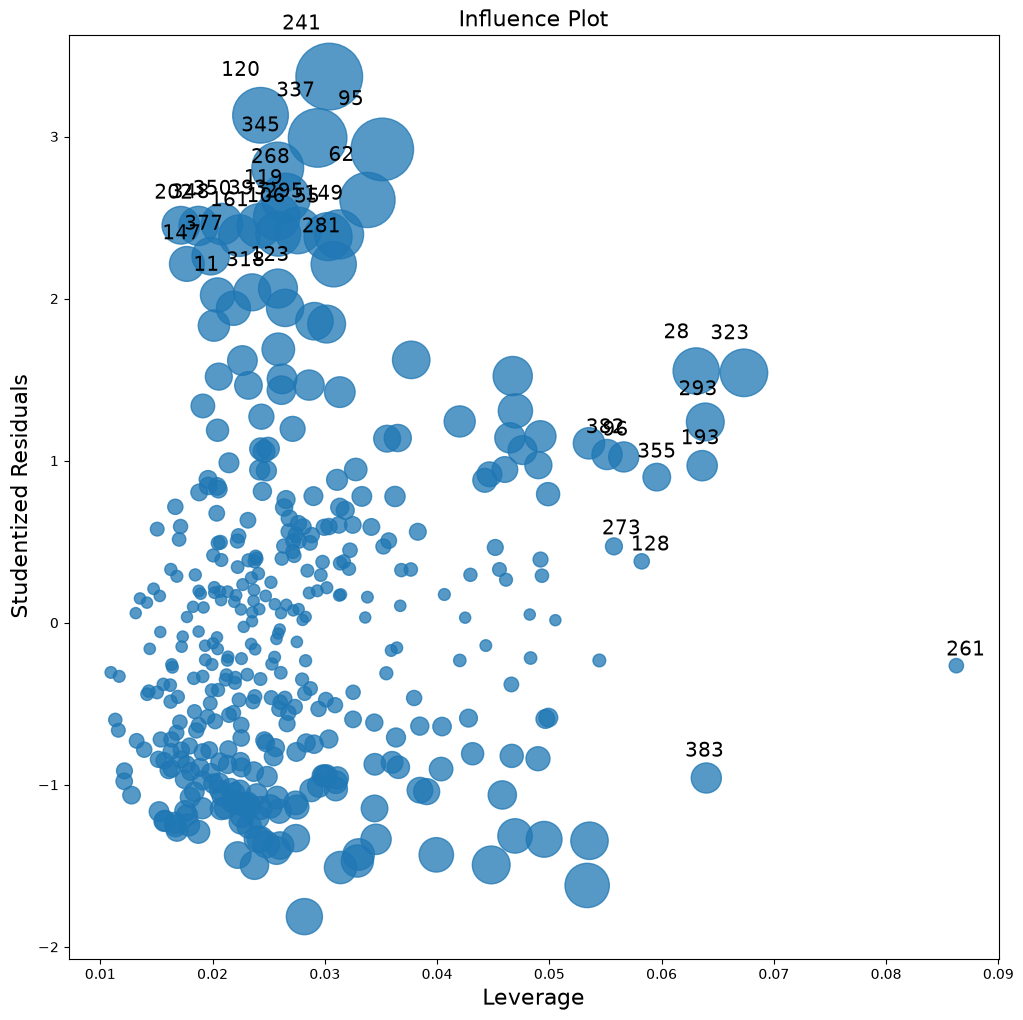

In [153]:
# graphical representation of the influence of each observation
fig, ax = plt.subplots(figsize=(12,12))
fig = sm.graphics.influence_plot(model, ax=ax, criterion="cooks") 
# size of points are given by cook's dist value
# the points with massive size whose studentized resids lie outside the range from (-3,3) should raise a "yellow" flag

Recall that we can do a test on the externally studentized residuals, using Student's t-distribution.

In [154]:
n=400
p=11

# Get the critical value for the t-distribution with n-p-1 degrees of freedom at the 97.5th percentile
tstar_stud = scipy.stats.t.ppf(0.975,df=n-p-1) 

# Extract the externally studentized residuals and identify which ones are atypical based on the critical value
reg_studs=infl.resid_studentized_external
atyp_stud = np.abs(reg_studs) > tstar_stud

print(credit.index[atyp_stud],reg_studs[atyp_stud])

Index([ 11,  55,  62,  95, 106, 119, 120, 123, 147, 149, 161, 202, 241, 268,
       281, 295, 318, 337, 345, 348, 350, 377, 393],
      dtype='int64') [2.02176216 2.38246237 2.60844946 2.92022236 2.39992104 2.50362966
 3.13098899 2.0621085  2.21384764 2.39576937 2.38857858 2.45235697
 3.36960249 2.62139386 2.21160112 2.42040229 2.0387421  2.99131062
 2.80569348 2.44838028 2.46010538 2.26155978 2.44955716]


Make note of the observations above that were 'detected' as outliers using the externally studentized residuals. 

Now, let's calculate the Cook's distance and use the $4/n$ rule-of-thumb to find the influential points. Then compare this with the observed outliers above, and also the influence plot. What do you notice?

In [155]:
#  Extract Cook's distance
inflsum = infl.summary_frame()
reg_cook = inflsum.cooks_d

atyp_cook = np.abs(reg_cook) >= 4/n
print(credit.index[atyp_cook],reg_cook[atyp_cook])

Index([ 28,  55,  62,  85,  95, 106, 119, 120, 123, 149, 161, 241, 268, 281,
       295, 320, 323, 337, 345, 348, 350, 393],
      dtype='int64') 28     0.014714
55     0.015926
62     0.021320
85     0.010291
95     0.027677
106    0.013727
119    0.014840
120    0.021679
123    0.010163
149    0.016639
161    0.011740
241    0.031517
268    0.016769
281    0.013987
295    0.014927
320    0.013412
323    0.015549
337    0.024110
345    0.018628
348    0.010278
350    0.011556
393    0.013335
Name: cooks_d, dtype: float64


## End-of-class exercises

**Exercise 1.** In the section on calculating VIF manually, what is the VIF for X1 when all predictors are included in the calculation?

In [156]:
# your work here


**Exercise 2.** In the perfectly-correlated simulated dataset (`df_perfect`, the 4-point
example near the end of the multicollinearity section), one eigenvalue of `XtX` is
essentially zero. Now compare the coefficient on `X2` in `model1` (fit with both `X1` and
`X2`) to the coefficient on `X2` in `model3` (fit with `X2` alone). What are the two values,
and how does the near-zero eigenvalue explain why they're so different?

In [157]:
# your work here


**Exercise 3.** In the Influential Points section, using the fitted `model` on the credit
data, how many observations were flagged as outliers by the externally studentized
residual test (the `tstar_stud` cutoff)? How many were flagged as influential by the
Cook's distance $4/n$ rule? How many observations show up on *both* lists?

In [158]:
# your work here
